# Air Quality Analysis and AQI Prediction System

# Install libraries:

In [44]:
pip install pandas numpy matplotlib seaborn scikit-learn

# Libraries are checking:

In [59]:
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import sklearn

    print("All required libraries are installed successfully!")

except ImportError as e:
    print("Missing library:", e)

All required libraries are installed successfully!


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Data Loader:
## This function is used to load the CSV dataset into the program using the pandas library

In [46]:

def load_data(file_path):
    data = pd.read_csv("/Volumes/MyDrive/JUPYTER_WORK/air_quality/c4_epa_air_quality.csv")
    print("Dataset Loaded Successfully")
    return data

df = load_data("c4_epa_air_quality.csv")
df.head()

Dataset Loaded Successfully


,Unnamed: 0,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
0,0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,0.473684,7
1,1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,0.263158,5
2,2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,0.111111,2
3,3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,0.300000,3
4,4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,0.215789,3


# Data Inspected:
## This function is used to examine the dataset structure, including rows, columns and missing values.

In [47]:

def inspect_data(data):
    print("Dataset Shape:", data.shape)
    print("\nColumns:")
    print(data.columns)
    print("\nMissing Values:")
    print(data.isnull().sum())

inspect_data(df)

Dataset Shape: (260, 10)

Columns:
Index(['Unnamed: 0', 'date_local', 'state_name', 'county_name', 'city_name',
       'local_site_name', 'parameter_name', 'units_of_measure',
       'arithmetic_mean', 'aqi'],
      dtype='object')

Missing Values:
Unnamed: 0          0
date_local          0
state_name          0
county_name         0
city_name           0
local_site_name     3
parameter_name      0
units_of_measure    0
arithmetic_mean     0
aqi                 0
dtype: int64


# Data cleaning:
## This function cleans the dataset by removing unnecessary columns and converting data types.

In [48]:

def clean_data(data):
    
    # Remove unwanted column
    data = data.drop(columns=["Unnamed: 0"])
    
    # Convert date column
    data["date_local"] = pd.to_datetime(data["date_local"])
    
    print("Data Cleaned Successfully")
    
    return data

df = clean_data(df)
df.head()

Data Cleaned Successfully


,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,0.473684,7
1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,0.263158,5
2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,0.111111,2
3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,0.300000,3
4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,0.215789,3


# Data analysis:
## This function performs basic statistical analysis of air quality data.

In [49]:

def analyze_data(data):
    
    print("AQI Statistics")
    print(data["aqi"].describe())
    
    print("\nTop Cities by Average AQI")
    
    city_aqi = data.groupby("city_name")["aqi"].mean().sort_values(ascending=False)
    print(city_aqi.head())

analyze_data(df)

AQI Statistics
count    260.000000
mean       6.757692
std        7.061707
min        0.000000
25%        2.000000
50%        5.000000
75%        9.000000
max       50.000000
Name: aqi, dtype: float64

Top Cities by Average AQI
city_name
Compton           40.00
Phoenix           33.25
San Bernardino    28.00
Las Vegas         28.00
Mira Loma         27.00
Name: aqi, dtype: float64


# Visualization:

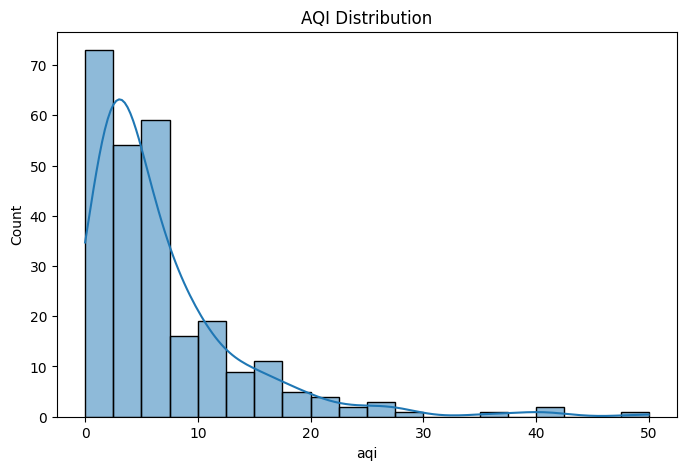

In [50]:

plt.figure(figsize=(8,5))
sns.histplot(df["aqi"], bins=20, kde=True)
plt.title("AQI Distribution")
plt.show()

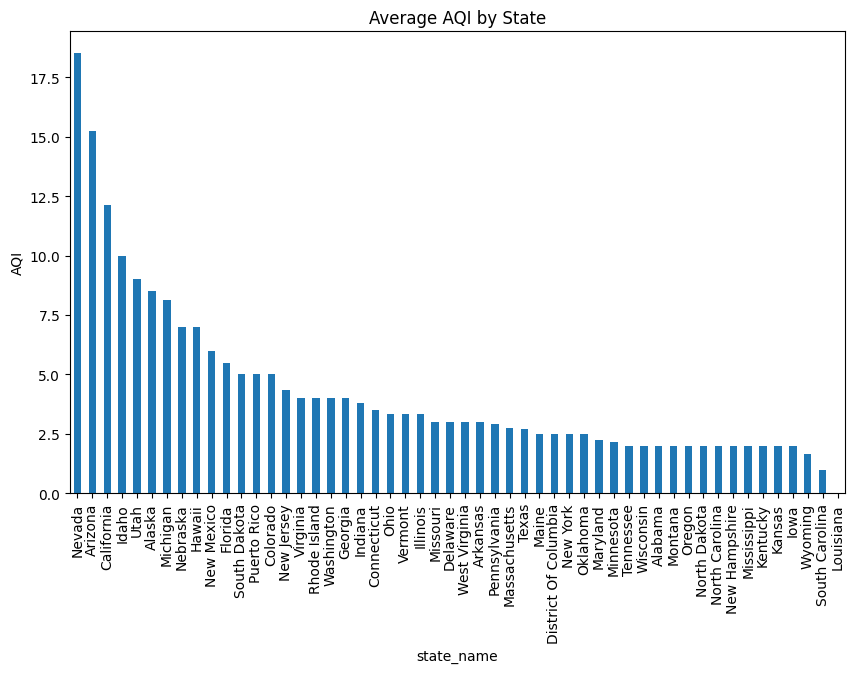

In [51]:
state_aqi = df.groupby("state_name")["aqi"].mean()

plt.figure(figsize=(10,6))
state_aqi.sort_values(ascending=False).plot(kind="bar")
plt.title("Average AQI by State")
plt.ylabel("AQI")
plt.show()

# Machine learing:

In [52]:

X = df[["arithmetic_mean"]]
y = df["aqi"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model:

In [53]:

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


# Model evaluation:

In [54]:

predictions = model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

Mean Absolute Error: 1.2355809337156531
R2 Score: 0.951207869875995


# APQ prediction function:

In [55]:

def predict_aqi(mean_pollution):
    
    prediction = model.predict([[mean_pollution]])
    
    print("Predicted AQI:", round(prediction[0],2))

predict_aqi(0.5)

Predicted AQI: 8.69


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


| Step | Role              | Description                  |
| ---- | ----------------- | ---------------------------- |
| 1    | Data Loader       | Load CSV dataset             |
| 2    | Data Inspector    | Check dataset structure      |
| 3    | Data Cleaner      | Remove unwanted data         |
| 4    | Data Analyst      | Perform statistical analysis |
| 5    | Visualization     | Generate graphs              |
| 6    | ML Engineer       | Train prediction model       |
| 7    | Prediction System | Predict AQI values           |
